In [3]:
# 1. Core libraries
import numpy as np
import pandas as pd

# 2. Viz
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Modeling utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 4. Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 5. Misc
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


In [8]:
import os

print("Current directory:", os.getcwd())
print("\nFiles here:", os.listdir())

# Check if 'data' folder exists
if os.path.exists("data"):
    print("\nFiles inside data/:", os.listdir("data"))
else:

    print("\nNo 'data' folder found.")


Current directory: /Users/anirudhhegde/Desktop/Northeastern University/Let's Do it/Projects/Telco-Customer-Churn/Notebooks

Files here: ['01_telco_churn_walkthrough.ipynb']

No 'data' folder found.


In [10]:
# 2. Load the Telco dataset
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.info()
df.isna().sum()
df["Churn"].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [12]:
# 3.1 Drop customerID (identifier)
df = df.drop(columns=["customerID"])

# 3.2 TotalCharges is read as object due to blanks; fix it
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 3.3 Handle nulls in TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 3.4 Make SeniorCitizen categorical (Yes/No)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})


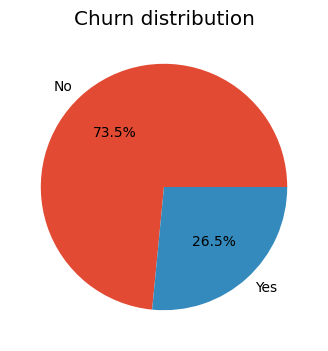

In [13]:
# Churn distribution
plt.figure(figsize=(4,4))
df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Churn distribution")
plt.ylabel("")
plt.show()


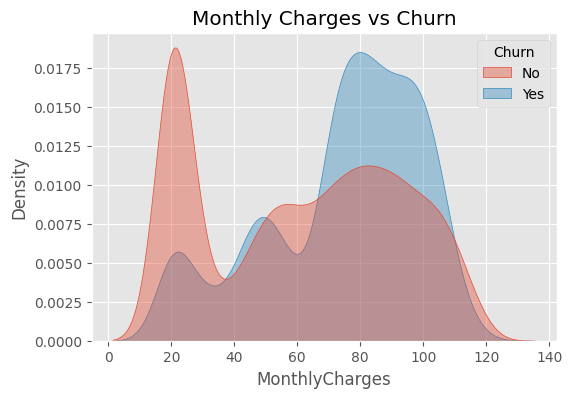

In [14]:
# MonthlyCharges distribution by churn
plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df, x="MonthlyCharges", hue="Churn", common_norm=False, fill=True, alpha=0.4
)
plt.title("Monthly Charges vs Churn")
plt.show()


In [15]:
# 5.1 Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})  # binary target

# 5.2 Identify column types
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
# 5.3 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
# 6.1 Preprocess numeric + categorical columns
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop=None,
    sparse_output=False
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [18]:
# 7. Logistic Regression pipeline with SMOTE
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

log_reg_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", log_reg),
])

log_reg_pipeline.fit(X_train, y_train)

y_pred = log_reg_pipeline.predict(X_test)
y_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]


/Users/anirudhhegde/Desktop/Northeastern University/Let's Do it/Projects/Telco-Customer-Churn/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anirudhhegde/Desktop/Northeastern University/Let's Do it/Projects/Telco-Customer-Churn/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anirudhhegde/Desktop/Northeastern University/Let's Do it/Projects/Telco-Customer-Churn/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/anirudhhegde/Desktop/Northeastern University/Let's Do it/Projects/Telco-Customer-Churn/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered 

In [19]:
def evaluate_classifier(y_true, y_pred, y_proba, model_name="model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)

    print(f"=== {model_name} ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print(f"ROC-AUC  : {roc:.3f}\n")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax[0])
    ax[0].set_title(f"{model_name} ROC")
    PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax[1])
    ax[1].set_title(f"{model_name} PR curve")
    plt.tight_layout()
    plt.show()


=== Logistic Regression + SMOTE ===
Accuracy : 0.737
Precision: 0.503
Recall   : 0.797
F1-score : 0.616
ROC-AUC  : 0.840

Confusion matrix:
[[740 295]
 [ 76 298]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



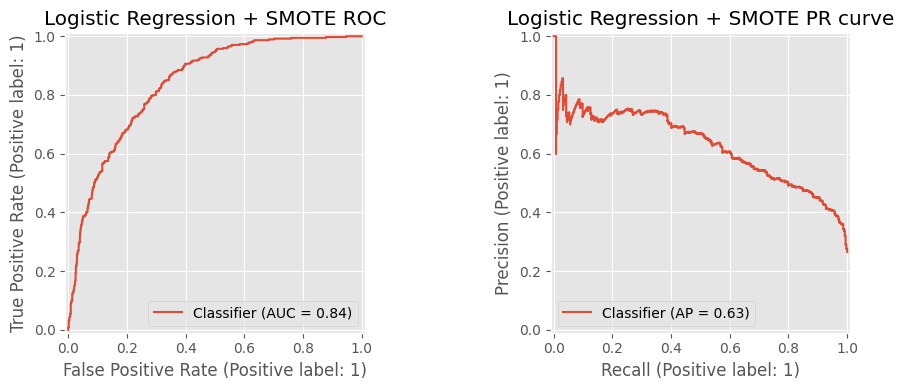

In [20]:
evaluate_classifier(y_test, y_pred, y_proba, model_name="Logistic Regression + SMOTE")


=== Random Forest + SMOTE ===
Accuracy : 0.774
Precision: 0.567
Recall   : 0.631
F1-score : 0.597
ROC-AUC  : 0.832

Confusion matrix:
[[855 180]
 [138 236]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.57      0.63      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



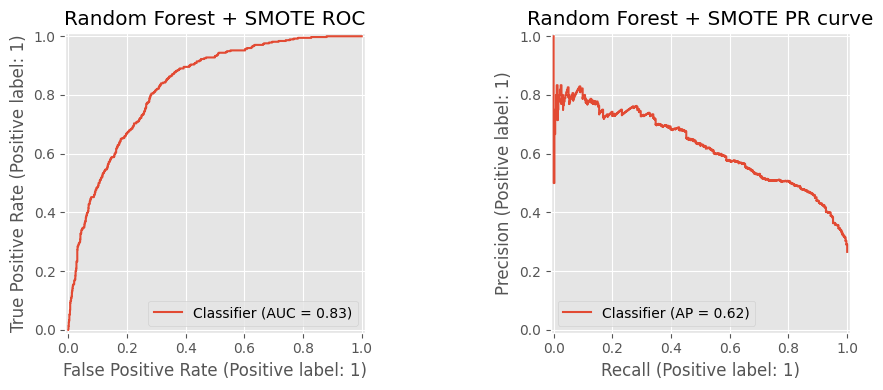

In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42,
)

rf_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", rf),
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

evaluate_classifier(y_test, y_pred_rf, y_proba_rf, model_name="Random Forest + SMOTE")


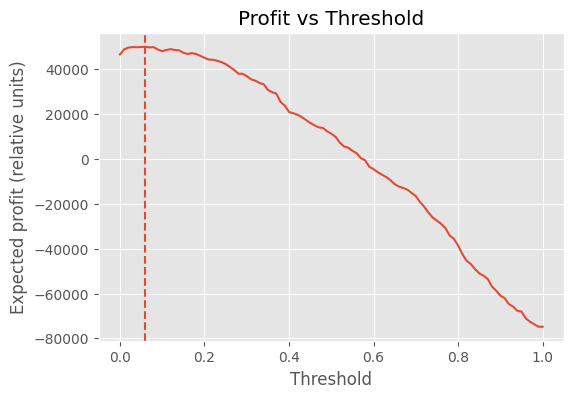

Best threshold: 0.06, Best profit (relative): 50060


(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 [np.float64(46620.0),
  np.float64(48860.0),
  np.float64(49660.0),
  np.float64(49900.0),
  np.float64(49840.0),
  np.float64(49920.0),
  np.float64(50060.0),
  np.float64(49760.0),
  np.float64(49880.0),
  np.float64(48760.0),
  np.float64(48080.0),
  np.float64(48600.0),
  np.float64(49000.0),
  np.float64(

In [22]:
def profit_curve(y_true, y_proba, c_churn=200.0, c_offer=20.0):
    thresholds = np.linspace(0, 1, 101)
    profits = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        # If we predict 1 (churn), we send an offer
        # TP: we save the customer → avoid churn loss but pay offer
        # FP: customer wouldn't churn but we still pay offer
        # FN: we lose the customer (no offer)
        # TN: nothing happens

        profit = (
            tp * (c_churn - c_offer)  # saved customers
            - fp * c_offer            # unnecessary offers
            - fn * c_churn            # lost customers
        )
        profits.append(profit)

    best_idx = int(np.argmax(profits))
    best_t = thresholds[best_idx]
    best_profit = profits[best_idx]

    plt.figure(figsize=(6,4))
    plt.plot(thresholds, profits)
    plt.axvline(best_t, linestyle="--")
    plt.title("Profit vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Expected profit (relative units)")
    plt.show()

    print(f"Best threshold: {best_t:.2f}, Best profit (relative): {best_profit:.0f}")
    return thresholds, profits

# Example on RF outputs
profit_curve(y_test, y_proba_rf)
